# AB Test Case Study

### Homework

Before you begin, remember to import the necessary libraries.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

The Marketing and Product teams are studying a new bundle-offer that they want to test in the checkout funnel of the e-commerce platform. In particular, once the user adds something to the cart, they will see an additional screen showing a special offer on a related product if they add it to the cart and purchase them together. 

To be sure that this is a good idea, they conducted an AB test and, after the fact, they call you in to analyse the results, to verify whether the increased conversion rate is statistically significant. 

1. The test results are in the `data/ab-test-homework.csv` csv file. Import them, familiarise yourself with the data and perform a permutation test to assess wether the treatment's higher conversion rate is statistically significant (note: control group = 'GRP A'; treatment group = 'GRP B'). 
2. Are you satisfied with the results? If you would have been consulted before the test, would you have done things differently?

***

In [3]:
df_raw = pd.read_csv('data/ab-test-homework.csv')

print(df_raw.info())
df_raw.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6177 entries, 0 to 6176
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   idUser       6177 non-null   int64 
 1   dtPurchased  6177 non-null   object
 2   nmGroup      6177 non-null   object
 3   isConv       6177 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 193.2+ KB
None


,idUser,dtPurchased,nmGroup,isConv
0,70893691,2017-08-02,GRP A,0
1,42506632,2017-08-21,GRP A,0
2,42520540,2017-09-30,GRP A,0
3,62816375,2017-05-31,GRP A,0
4,62801089,2017-06-28,GRP A,0


In [11]:
# Copy DF and convert data time
df = df_raw.copy()

df['dtPurchased'] = pd.to_datetime(df['dtPurchased'])

print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6177 entries, 0 to 6176
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   idUser       6177 non-null   int64         
 1   dtPurchased  6177 non-null   datetime64[ns]
 2   nmGroup      6177 non-null   object        
 3   isConv       6177 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 193.2+ KB
None


,idUser,dtPurchased,nmGroup,isConv
0,70893691,2017-08-02,GRP A,0
1,42506632,2017-08-21,GRP A,0
2,42520540,2017-09-30,GRP A,0
3,62816375,2017-05-31,GRP A,0
4,62801089,2017-06-28,GRP A,0


In [14]:
# check

df.groupby(['nmGroup', 'isConv'], as_index=False).size()

,nmGroup,isConv,size
0,GRP A,0,2218
1,GRP A,1,811
2,GRP B,0,2233
3,GRP B,1,915


In [ ]:
# test Statistic

mu_control = np.mean(df[df['nmGroup']=='GRP A']['isConv'])
mu_treatment = np.mean(df[df['nmGroup']=='GRP B']['isConv'])
mu_diff = mu_treatment - mu_control
print('Observed test statistic:', mu_diff)

Observed test statistic: 0.022915606569783087


In [17]:
n = 500
mu_diff_samples = []
for i in range(n): 
    # extract a subsample of 50% of data without replacement
    df_sample1 = df.sample(frac=0.5, replace=False)
    # use set() to get indexes of rows that were not extracted from df in previous step
    ix2 = set(df.index) - set(df_sample1.index)
    # create dataframe with other 50% of data
    df_sample2 = df.loc[list(ix2)]
    # calculate difference in mean from each sample
    mu_diff_temp = np.mean(df_sample1['isConv']) - np.mean(df_sample2['isConv'])
    # append sampled mean difference to mu_diff_samples list
    mu_diff_samples.append(mu_diff_temp)

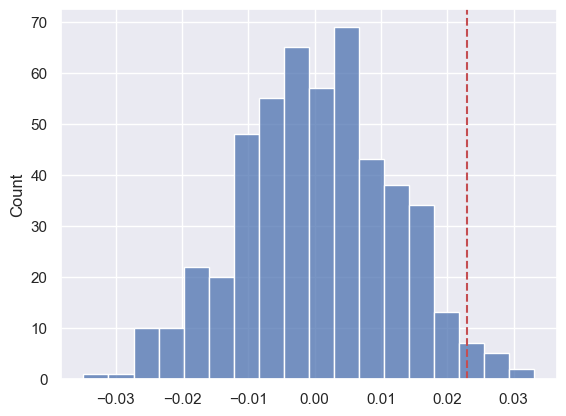

Average Simulated Test Statistic: 0.0002
Initially Observed Test Statistic: 0.0229


In [18]:
sns.histplot(mu_diff_samples)
plt.axvline(mu_diff, 0, 1, color='r', linestyle='--')
plt.show()
print('Average Simulated Test Statistic:', f'{np.mean(mu_diff_samples):.4f}')
print('Initially Observed Test Statistic:', f'{mu_diff:.4f}')

In [19]:
print('Results more extreme than observed:', sum([el >= mu_diff for el in mu_diff_samples]))
print('Total results:', len(mu_diff_samples))
p_value = sum([el > mu_diff for el in mu_diff_samples])/n
print('p-value:', sum([el >= mu_diff for el in mu_diff_samples]), '/', len(mu_diff_samples), '=', p_value)

Results more extreme than observed: 11
Total results: 500
p-value: 11 / 500 = 0.022


In [20]:
alpha = 0.1

if p_value <= alpha: 
    print('H0 rejected: the observed result is statistically significant | p-value <= alpha')
else: 
    print('H0 accepted | the observed result is not statistically significant | p-value > alpha')

H0 rejected: the observed result is statistically significant | p-value <= alpha
